In [267]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [269]:
#FUNCTIONS
# Function to compute forces based on Lennard-Jones potential
def calculate_forces(positions):
    forces = np.zeros_like(positions)
    for i in range(num_particles):
        for j in range(i + 1,num_particles):
            displacement = positions[i] - positions[j]
            displacement -= np.round(displacement / size_of_box) * size_of_box 
            r = np.linalg.norm(displacement)
            if r < Rc:  #Rc=cut off radius
                force = 48  *(1/r**14 - 0.5/r**8)*  displacement
                forces[i] += force
                forces[j] -= force
    return forces

# Lennard-Jones potential 
def lj_potential(distances):
    lj_potential=4 * epsilon * ((sigma / distances) ** 12 - (sigma / distances) ** 6)
    return lj_potential


#a function for updating particle position and velocity
def update_p_v(frame):
    global initial_forces , velocities, positions 
    initial_forces = calculate_forces(positions)
    #x=0.5at^2+vt
    positions += velocities * DT + 0.5 * forces * DT**2
    final_forces = calculate_forces(positions)
    #0.5(f0+f1)t
    velocities += 0.5 * (forces + final_forces) * DT
    positions %= size_of_box
    scat.set_offsets(positions)

# Function to update positions
def update_positions(initial_positions, velocities):
    #x=vt+x0
    new_positions = velocities * DT + initial_positions  
    new_positions %= size_of_box # Teleport to opposite side if out of bounds
    return new_positions


def plot_multiple_steps(start_step, num_plots):
    plt.figure(figsize=(8, 8))

    for i in range(num_plots):
        step = start_step + i
        if step >= STEPS:
            break  # Avoid out of bounds

        plt.subplot(2, 2, i + 1)  # Create a 2x2 grid for plotting
        plt.xlim(0,size_of_box )
        plt.ylim(0, size_of_box )
        plt.title(f'Particle Positions at frame {step}')
        plt.xlabel('X ')
        plt.ylabel('Y ')

        # Plot current particle positions
        plt.scatter(positions_frame[step][:, 0], positions_frame[step][:, 1], color='purple')
        plt.grid()

    plt.tight_layout()
    plt.show()

# Function to initialize the scatter plot
def initial():
    scatter.set_offsets(np.empty((0, 2)))  # Ensure it's a 2D array
    return scatter,

# Function to update the scatter plot for each frame
def update_frame(frame):
    scatter.set_offsets(positions_frame[frame])  # This should always be 2D
    return scatter,

def position_vs_time(positions_frame):
    fig, ax = plt.subplots()

    for i in range(num_particles):
        x = [position[i][0] for position in positions_frame]
        y = [position[i][1] for position in positions_frame]

        ax.plot(x, y, label=f'Particle {i+1}')
        
        # Plot the last position of each particle
        ax.scatter(x[-1], y[-1], color='blue', s=6, zorder=1)  # Red dot for the last position

    ax.set_title('Particle Positions Over Time')
    ax.set_xlabel('X ')
    ax.set_ylabel('Y ')
    
    # Set legend position to the right of the plot
    ax.legend(loc='upper left', bbox_to_anchor=(2, 2)) 
    ax.grid() 
    plt.tight_layout()  
    plt.savefig("particle_trajectory.png")
    plt.show()


In [277]:
# Constants for Argon (in dimensionless units)
length_of_argon = 3.4e-10  # m
energy_of_argon= 1.65e-21  # J
mass_of_argon = 6.69e-26    # kg

# Derived constants
time_of_argon = length_of_argon * ( mass_of_argon /energy_of_argon) ** 0.5  # s
velocity_of_argon = (energy_of_argon / mass_of_argon) ** 0.5  # m/s
force_of_argon = energy_of_argon /length_of_argon  # N
Rc = 2.5 * length_of_argon / length_of_argon  # Cutoff radius in dimensionless units

# Constants for Argon (in reduced units)
sigma = length_of_argon / length_of_argon  # Lennard-Jones diameter (dimensionless)
epsilon = energy_of_argon /energy_of_argon  # Lennard-Jones depth (dimensionless)

# Simulation parameters
num_particles = 36     # Number of particles
size_of_box = 10        # Box size in dimensionless units
DT = 0.005         # Time step in dimensionless units
TOTAL_TIME = 5      # Total simulation time in dimensionless units
STEPS = int(TOTAL_TIME / DT)  # Total number of steps


In [279]:
# Initialize positions on a regular lattice in tow dimensions
size_of_lattice = int(np.sqrt(num_particles))
positions = np.zeros((num_particles, 2))
for i in range(size_of_lattice):
    for j in range(size_of_lattice):
        if i * size_of_lattice + j < num_particles:
            positions[i * size_of_lattice + j] = [i*(size_of_box/size_of_lattice), j * (size_of_box /size_of_lattice)]

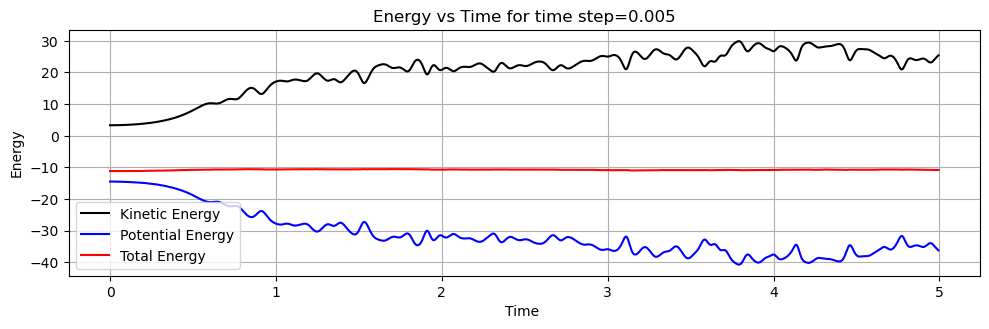

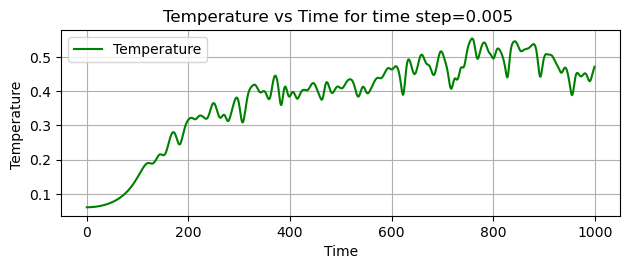

In [282]:
# Initialize random velocities
np.random.seed(42)  # For reproducibility
velocities = np.random.rand(num_particles, 2) - 0.5

kinetic_energies_list = []
potential_energies_list = []
total_energies_list = []
temperature_list = []

for step in range(STEPS):
    initial_forces = calculate_forces(positions)

    # Update positions using Verlet's method
    positions += velocities * DT + 0.5 * initial_forces * DT**2

    # Update velocities
    final_forces = calculate_forces(positions)
    velocities += 0.5 * (initial_forces + final_forces) * DT

    # Periodic boundary conditions
    positions %= size_of_box

    # Calculate total energy
    kinetic_energy = 0.5 * np.sum(velocities**2)
    temperature = kinetic_energy / (num_particles * 1.5)  # Correct temperature calculation based on degrees of freedom
    potential_energy = 0.0
    for i in range(num_particles):
        for j in range(i + 1, num_particles):
            displacement = positions[i] - positions[j]
            displacement -= np.round(displacement / size_of_box) * size_of_box
            r = np.linalg.norm(displacement)
            if r < Rc:
                potential_energy += 4 * epsilon * ((sigma/r)**12 - (sigma/r)**6)

    potential_energies_list.append(potential_energy)
    kinetic_energies_list.append(kinetic_energy)
    total_energy = kinetic_energy + potential_energy
    total_energies_list.append(total_energy)
    temperature_list.append(temperature)

# Plotting energy vs time steps
time_steps = np.arange(STEPS) * DT

plt.figure(figsize=(10, 6))
# Energy plot                   
plt.subplot(2, 1, 1)                   
plt.plot(time_steps, kinetic_energies_list, label='Kinetic Energy', color='black')
plt.plot(time_steps, potential_energies_list, label='Potential Energy', color='blue')
plt.plot(time_steps, total_energies_list, label='Total Energy', color='red')
plt.title('Energy vs Time for time step=0.005')
plt.xlabel('Time ')
plt.ylabel('Energy')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("energy_n=401.png")
plt.show()


# Temperature plot
plt.subplot(2, 1, 2)
plt.plot(temperature_list, label='Temperature', color='green')
plt.title('Temperature vs Time for time step=0.005 ')
plt.xlabel('Time')
plt.ylabel('Temperature ')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("dama_n=401.png")
plt.show()

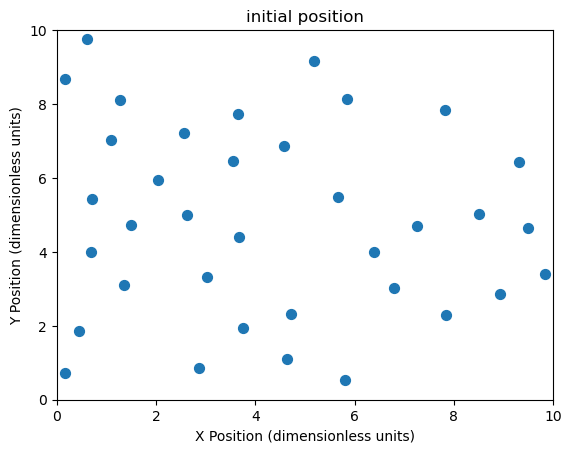

In [253]:
# Visualization of particle trajectories
fig, ax = plt.subplots()
#setting limits for horizontal and vertical axes
ax.set_xlim(0, size_of_box)
ax.set_ylim(0, size_of_box)
#scatter plot of partices based on their positions
scat = ax.scatter(positions[:, 0], positions[:, 1], s=50)

#ani = FuncAnimation(fig, update_p_v, frames=STEPS, interval=50)
plt.title("initial position")
plt.xlabel("X Position (dimensionless units)")
plt.ylabel("Y Position (dimensionless units)")
plt.savefig("avalie0.01.png")
plt.show()

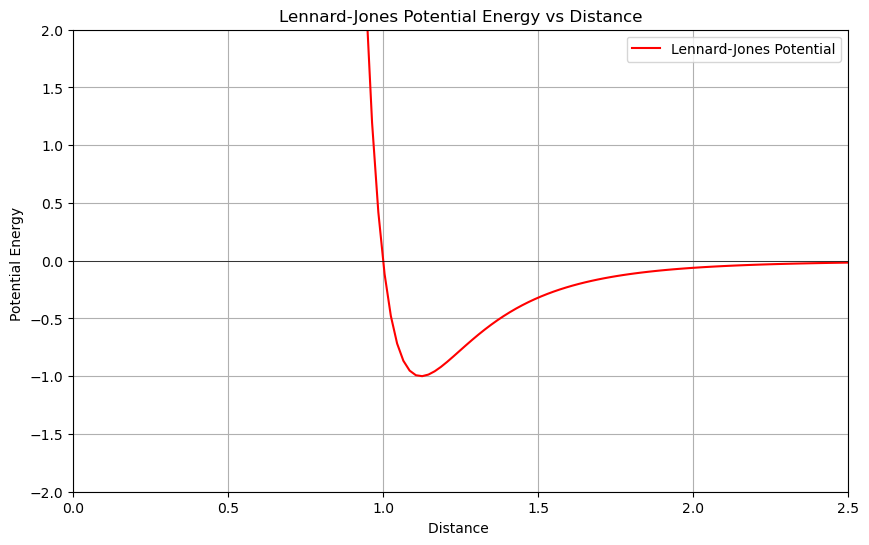

In [254]:
# Generate a range of distances between 0.5 and 2.5 ,distances can not be 0 because there is a singularity
distances = np.linspace(0.5 *sigma, 2.5  *sigma, 100)  
energy_values = lj_potential(distances)

# Normalize by epsilon and convert distances to reduced units (r/sigma)
r_reduced = distances / sigma
energy_reduced = energy_values / epsilon

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(r_reduced, energy_reduced, label='Lennard-Jones Potential', color='red')
plt.title('Lennard-Jones Potential Energy vs Distance')
plt.xlabel('Distance ')
plt.ylabel('Potential Energy ')
plt.axhline(0, color='black', lw=0.5, ls='-')  # Add a horizontal line at U = 0
plt.xlim(0, 2.5)
plt.ylim(-2, 2)  # Adjust limits for better visualization
plt.grid()
plt.legend()
plt.savefig("ljpotential_n=41.png")
plt.show()

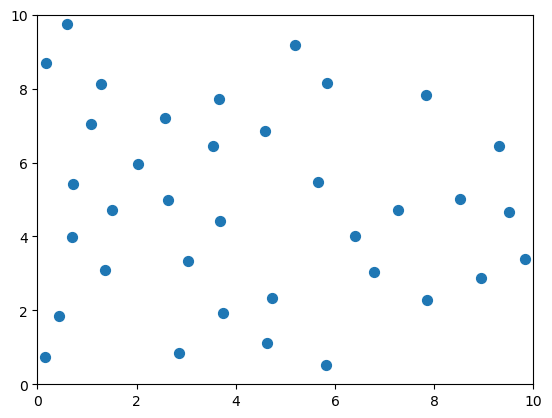

In [255]:
# Visualization of particle trajectories
fig, ax = plt.subplots()
ax.set_xlim(0, size_of_box)
ax.set_ylim(0, size_of_box)
scat = ax.scatter(positions[:, 0], positions[:, 1], s=50)



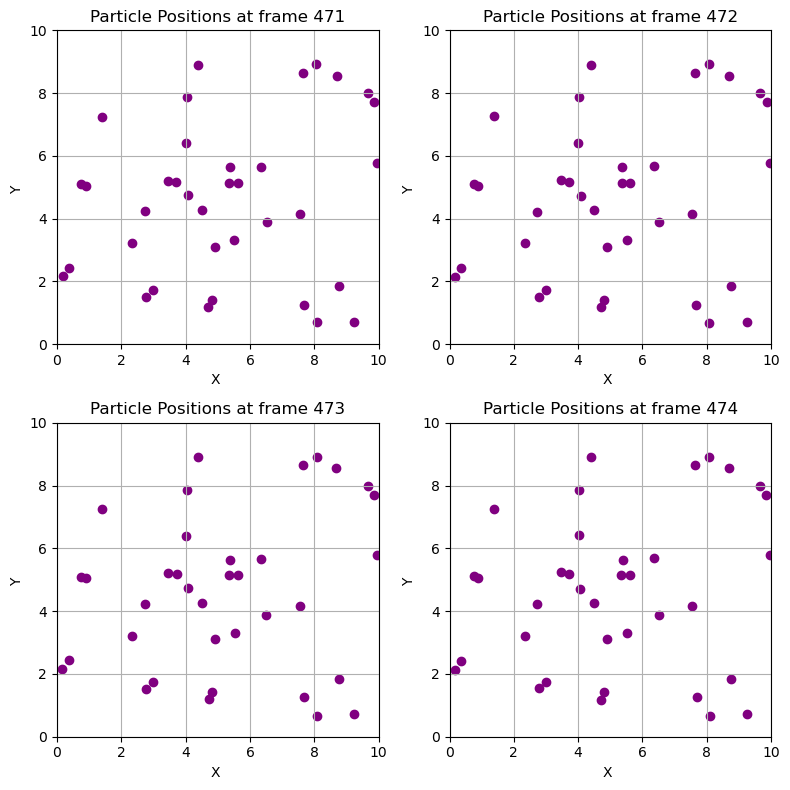

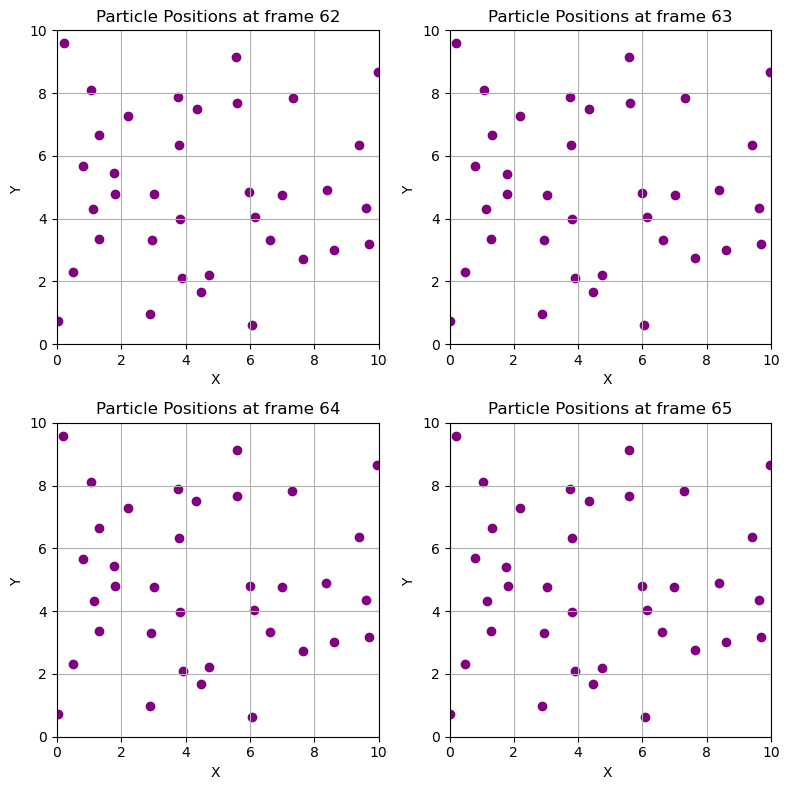

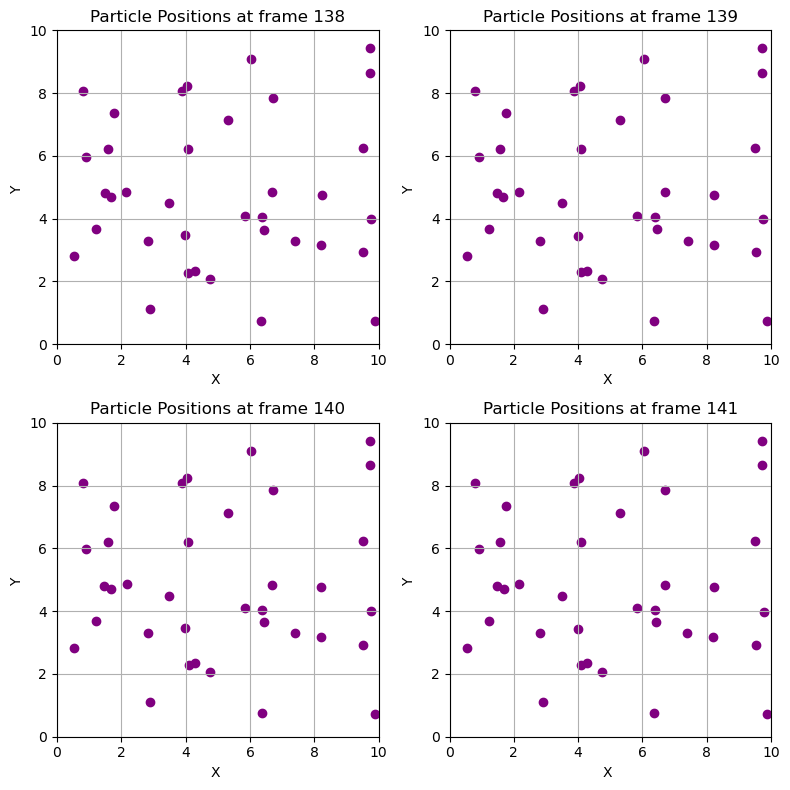

In [256]:
# showing  positions for every frame
positions_frame = []

# simulation
for step in range(STEPS):
    positions = update_positions(positions, velocities)
    positions_frame.append(positions.copy())
    # Function to plot multiple steps

# Choose how many times to plot random steps
num_iterations = 3  # Number of times to repeat the plotting

for _ in range(num_iterations):
    random_start_step = np.random.randint(0, STEPS - 4)  # Ensure enough steps remain
    num_plots = 4

    # Plot the selected steps
    plot_multiple_steps(random_start_step, num_plots)

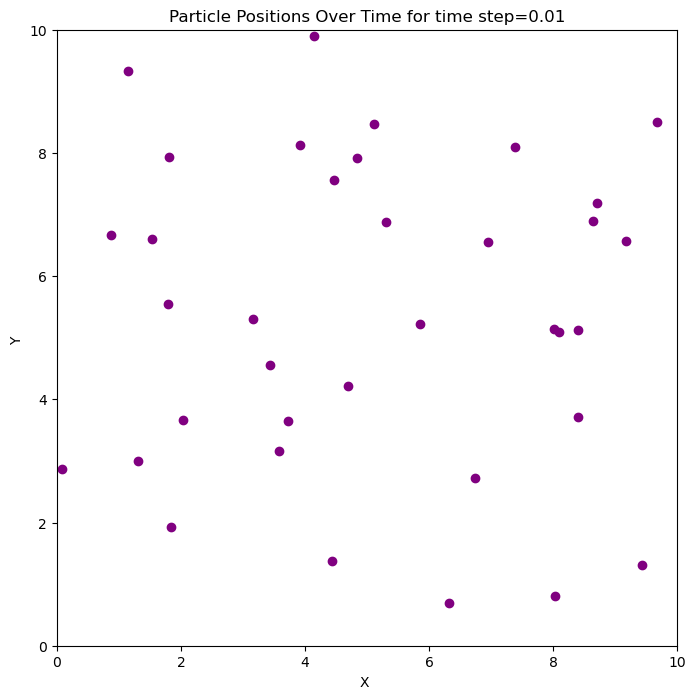

In [257]:
# video of positions 

# Store history for visualization
positions_frame = []
# Run the simulation
for step in range(STEPS):
    positions = update_positions(positions, velocities)
    positions_frame.append(positions.copy())

# Create a figure for animation
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, size_of_box)
ax.set_ylim(0,  size_of_box)
ax.set_title('Particle Positions Over Time for time step=0.01')
ax.set_xlabel('X ')
ax.set_ylabel('Y ')
scatter = ax.scatter([], [], color='purple')


# Create animation
ani = FuncAnimation(fig, update_frame, frames=STEPS, init_func=initial, blit=True)
#ani = FuncAnimation(fig, update, frames=STEPS, blit=True)

# Save the animation as a GIF file using Pillow
ani.save('particle_simulation_n=4.gif', writer='pillow', fps=10)

plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7616\4040332972.py:93: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


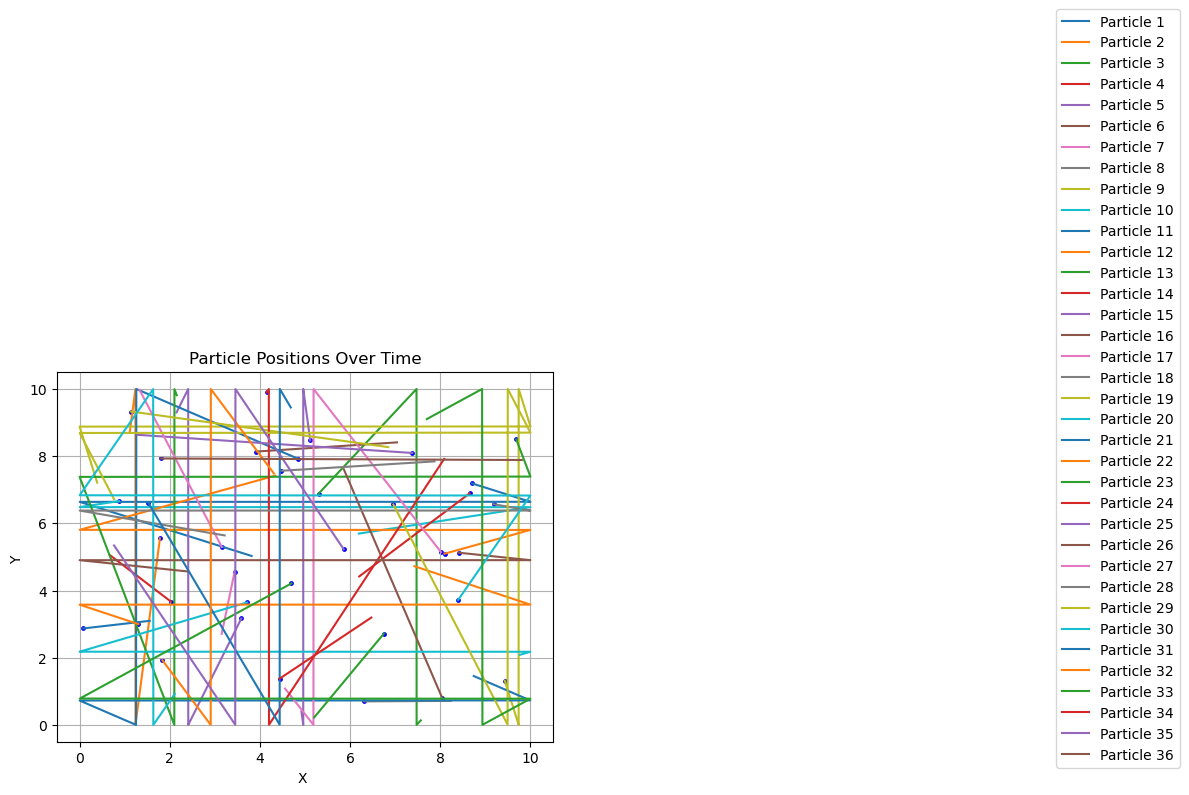

In [258]:
# Position vs Time plot

position_vs_time(positions_frame)
